## Context engineering in Deep Agents
Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably. Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

### Basic deep agent

In [5]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPEN_API_KEY"]=os.getenv("OPEN_API_KEY")
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

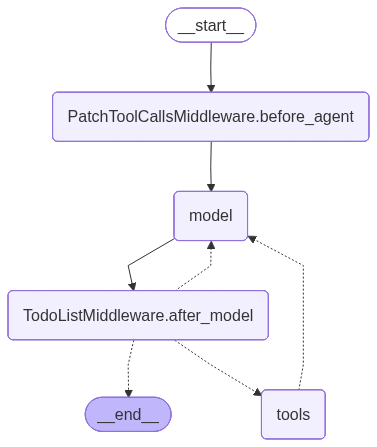

In [17]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model="google_genai:gemini-2.5-flash-lite", ##openai:gpt-5.5
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources. Use subagents for parallel research on different topics."

    ),
)
agent

In [18]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result['messages']

[HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='21323cae-ab05-4a49-a998-1bbb7880a7d3'),
 AIMessage(content='', additional_kwargs={'function_call': {'name': 'read_file', 'arguments': '{"file_path": "/README.md"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea0ba-f852-7a23-98c0-8e81f454e5f5-0', tool_calls=[{'name': 'read_file', 'args': {'file_path': '/README.md'}, 'id': 'd5ecafbd-474a-4716-a6ba-3d463da54462', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 5934, 'output_tokens': 19, 'total_tokens': 5953, 'input_token_details': {'cache_read': 0}}),
 ToolMessage(content="Error: File '/README.md' not found", name='read_file', id='51ccd310-d409-41a3-ae15-63c10d8657ad', tool_call_id='d5ecafbd-474a-4716-a6ba-3d463da54462', status='error'),
 AIMessage(content='I am a large language model, trained by Google.', 

In [21]:
print(result['messages'][-1].content)

I am an AI assistant designed to help users with their tasks. I can interact with various tools, process information, and generate responses. My goal is to be a helpful and efficient research assistant.


## Context Engineering with `AGENTS.md`

Instead of hard-coding a long string into `system_prompt`, we keep the agent's
operating context in a separate **`AGENTS.md`** file. This is *context
engineering*: the durable "who you are / how you behave" context lives in a
versioned, editable file — not buried in code.

In [22]:
from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md


'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [23]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

## Backends: where the agent's files / memory live

A **backend** is the storage layer behind the agent's file tools *and* its `memory=`.
Same agent code, different durability:

| Backend | Lives in | Survives across | Use it when… |
|---------|----------|-----------------|--------------|
| **StateBackend** (default) | LangGraph state (the `files` channel) | one thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | everything (it's just files) | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | **all threads** (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [25]:
agent = create_deep_agent(
    model="google_genai:gemini-2.5-flash-lite",
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I am a deep agent, designed for complex, multi-step, long-horizon tasks. I should follow the operating guidelines outlined in this `Agents.md` file, which include planning first, offloading aggressively to files, delegating wisely to subagents, and providing concise, synthesized final answers that cite sources.


In [26]:
# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

agent=create_deep_agent(
    model="google_genai:gemini-2.5-flash-lite",
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(),
)


In [27]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, 

In [28]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I am a large language model, trained by Google. I have access to tools that allow me to interact with the file system, manage tasks, and use subagents for complex operations. I don't have personal memories in the way humans do, but I can access and process information from files loaded into my context, such as the `Agents.md` file, which describes my architecture and operating guidelines.


In [ ]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model="google_genai:gemini-2.5-flash-lite",
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)

print(result["messages"][-1].content)

I am a large language model, trained by Google. I have access to a filesystem and a set of tools that allow me to interact with it and execute code. I do not have memory in the same way a human does, but I can use tools like `read_file` and `write_file` to interact with files if needed.


In [30]:
result

{'messages': [HumanMessage(content="What's in your memory? Who are you?", additional_kwargs={}, response_metadata={}, id='480455bb-63a4-4899-8369-af49af11463e'), AIMessage(content='I am a large language model, trained by Google. I have access to a filesystem and a set of tools that allow me to interact with it and execute code. I do not have memory in the same way a human does, but I can use tools like `read_file` and `write_file` to interact with files if needed.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea0c9-ca12-7db2-b8c8-b4a91f24e8d2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7097, 'output_tokens': 70, 'total_tokens': 7167, 'input_token_details': {'cache_read': 0}})], 'files': {}}

In [31]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model="google_genai:gemini-2.5-flash-lite",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

I am a deep agent, an AI assistant designed for complex, multi-step tasks. I use a planning tool to break down tasks, a file system for context offloading, and can spawn subagents for specialized work. I have access to tools like `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`, `write_todos`, and `task`. My goal is to help you accomplish your tasks efficiently and accurately.

I don't have personal memories in the way humans do. However, I can access and modify files in my environment. This includes a file named `Agents.md` which contains information about my architecture and operating guidelines.


In [32]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

LLM Gateways (or Large Language Model Gateways / AI Gateways) are systems that act as a central intermediary between users/applications and one or more Large Language Models (LLMs). They provide a unified access point, manage model routing, abstract complexity, optimize costs, enhance security, and offer monitoring capabilities.

Key functions include:
*   **Unified API Access:** A single interface for multiple LLMs.
*   **Model Routing:** Directing requests to the best LLM for the task.
*   **Cost Management:** Tracking usage and optimizing spending.
*   **Security:** Managing credentials and access control.
*   **Monitoring:** Providing analytics on performance and usage.
*   **Caching:** Storing frequent responses to reduce latency and cost.

These gateways simplify LLM integration, offer flexibility in model choice, improve security, and provide better cost control and performance monitoring. They are essential for enterprises looking to leverage LLMs effectively in their applicati

#### Skills


Skills are reusable agent capabilities that provide specialized workflows and domain knowledge.
You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository.
Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [1]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}


In [2]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [3]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [6]:
agent=create_deep_agent(
    model="google_genai:gemini-2.5-flash-lite",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

I have the following skills:

* **aws**: Use for AWS services, architecture, boto3/AWS CLI, cost optimization, or cloud security.
* **langgraph**: Use for LangGraph, stateful workflows, nodes, edges, routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents.
* **python**: Use for Python code (writing, debugging, refactoring, explaining, reviewing), or Python concepts.
* **report-writer**: Use after answering a query to write a markdown report of the interaction.

I can also use the `task` tool to launch subagents for complex, isolated tasks, and the `write_todos` tool to manage task lists.


In [7]:
result

{'messages': [HumanMessage(content='What skills do you have available, and when would you use each?', additional_kwargs={}, response_metadata={}, id='8ebc056d-7977-45c5-8e4e-15ed889d899e'),
  AIMessage(content='I have the following skills:\n\n* **aws**: Use for AWS services, architecture, boto3/AWS CLI, cost optimization, or cloud security.\n* **langgraph**: Use for LangGraph, stateful workflows, nodes, edges, routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents.\n* **python**: Use for Python code (writing, debugging, refactoring, explaining, reviewing), or Python concepts.\n* **report-writer**: Use after answering a query to write a markdown report of the interaction.\n\nI can also use the `task` tool to launch subagents for complex, isolated tasks, and the `write_todos` tool to manage task lists.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_pr

In [8]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================
Tool Calls:
  read_file (a60ae5ad-4149-48eb-bf4b-9a5930e16648)
 Call ID: a60ae5ad-4149-48eb-bf4b-9a5930e16648
  Args:
    file_path: /skills/langgraph/SKILL.md
================================= Tool Message =================================
Name: read_file

     1	---
     2	name: langgraph
     3	description: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.
     4	license: MIT
     5	metadata:
     6	  version: "1.0"
     7	  author: d

In [9]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do i set up an EC2  insstance in AWS.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-3"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do i set up an EC2  insstance in AWS.
================================== Ai Message ==================================
Tool Calls:
  read_file (b09159a2-cb02-48a9-b2f1-2543b51270ce)
 Call ID: b09159a2-cb02-48a9-b2f1-2543b51270ce
  Args:
    file_path: /skills/aws/SKILL.md
================================= Tool Message =================================
Name: read_file

     1	---
     2	name: aws
     3	description: AWS cloud expertise. Use when the user asks about AWS services (EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker), architecture design on AWS, boto3 / AWS CLI usage, cost optimization, or cloud security best practices. Provides decision frameworks, CLI/boto3 workflows, and worked examples.
     4	license: MIT
     5	metadata:
     6	  version: "1.0"
     7	  author: deepagentscourse
     8	---
     9	
    10	# AWS Skill
    11	
    12	You are acting as an AWS so

In [10]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "write me a python code to do binary search",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-4"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

write me a python code to do binary search
================================== Ai Message ==================================
Tool Calls:
  write_file (74372bf0-4371-4ec3-9109-e6b59b08772b)
 Call ID: 74372bf0-4371-4ec3-9109-e6b59b08772b
  Args:
    file_path: /binary_search.py
    content: 
def binary_search(arr, target):
    """
    Performs binary search on a sorted array.

    Args:
        arr: A sorted list of elements.
        target: The element to search for.

    Returns:
        The index of the target element if found, otherwise -1.
    """
    left, right = 0, len(arr) - 1

    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return -1

if __name__ == "__main__":
    # Example usage:
    my_list = [2, 5, 7, 8, 11, 12]
    search_tar